## <span style="color: deeppink">Intro:</span> 
In this project, given a dataset of different taxi price forming components, I aim to predict taxi prices using multiple regression techniques: **Linear Regression**, **Ridge**, **Lasso**, and **Polynomial Regression**.

The dataset contains various trip features such as distance, duration, rate per km, and categorical variables like payment type and traffic conditions. The pipeline includes data cleaning, handling missing values, encoding categorical features, exploratory data analysis **(EDA)**, model training, and performance evaluation using **R²** and **RMSE** metrics.

The goal is to identify which model best generalizes to unseen data while avoiding overfitting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [2]:
data = pd.read_csv('taxi_trip_pricing.csv')
data.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.51,1.66,NaN,5.05,11.2645
7,43.44,Evening,Weekend,3.0,NaN,Clear,2.97,1.87,0.23,NaN,101.1216
8,30.45,Morning,Weekday,3.0,High,Clear,2.77,1.78,0.34,110.33,NaN
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.39,1.52,0.47,NaN,75.5657


In [3]:
print(data.shape)
print(data.dtypes)

(1000, 11)
Trip_Distance_km         float64
Time_of_Day                  str
Day_of_Week                  str
Passenger_Count          float64
Traffic_Conditions           str
Weather                      str
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object


In [4]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [5]:
data.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [6]:
data = data.dropna(subset=['Trip_Price'])

In [7]:
for feature in data.columns[:-1]:
    if data[feature].dtype == 'float64':
        data[feature] = data[feature].fillna(data[feature].mean())
    else:
        a = data[feature].value_counts(normalize = True, dropna = True)
        data[feature] = data[feature].apply(lambda x: np.random.choice(a.keys(), p = a.values) if pd.isna(x) else x)

In [8]:
data.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

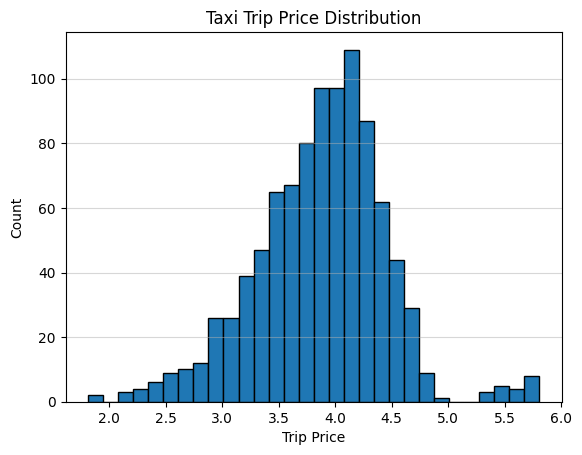

In [9]:
plt.hist(np.log(data['Trip_Price']), bins = 30, edgecolor = 'black')
plt.xlabel('Trip Price')
plt.ylabel('Count')
plt.title('Taxi Trip Price Distribution')
plt.grid(axis = 'y', alpha = 0.5)
plt.show()

In [10]:
for feature in data.columns[:-1]:
    if data[feature].dtype == 'str':
        counts = data[feature].value_counts()
        for v in counts.keys():
            data[f"{feature}({v})"] = (data[feature] == v).astype('int8')
        data.drop(feature, axis = 1, inplace = True)
        

In [11]:
data

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day(Afternoon),Time_of_Day(Morning),Time_of_Day(Evening),Time_of_Day(Night),Day_of_Week(Weekday),Day_of_Week(Weekend),Traffic_Conditions(Low),Traffic_Conditions(Medium),Traffic_Conditions(High),Weather(Clear),Weather(Rain),Weather(Snow)
0,19.350000,3.0,3.56,0.800000,0.320000,53.82,36.2624,0,1,0,0,1,0,1,0,0,1,0,0
2,36.870000,1.0,2.70,1.210000,0.150000,37.27,52.9032,0,0,1,0,0,1,0,0,1,1,0,0
3,30.330000,4.0,3.48,0.510000,0.150000,116.81,36.4698,0,0,1,0,1,0,1,0,0,1,0,0
4,27.190998,3.0,2.93,0.630000,0.320000,22.64,15.6180,0,0,1,0,1,0,0,0,1,1,0,0
5,8.640000,2.0,2.55,1.710000,0.480000,89.33,60.2028,1,0,0,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,4.0,2.39,0.620000,0.490000,58.39,34.4049,1,0,0,0,0,1,0,1,0,1,0,0
996,45.950000,4.0,3.12,0.610000,0.293902,61.96,62.1295,0,0,0,1,1,0,0,1,0,1,0,0
997,7.700000,3.0,2.08,1.780000,0.293902,54.18,33.1236,0,1,0,0,1,0,1,0,0,0,1,0
998,47.560000,1.0,2.67,0.820000,0.170000,114.94,61.2090,0,1,0,0,1,0,1,0,0,1,0,0


<Axes: >

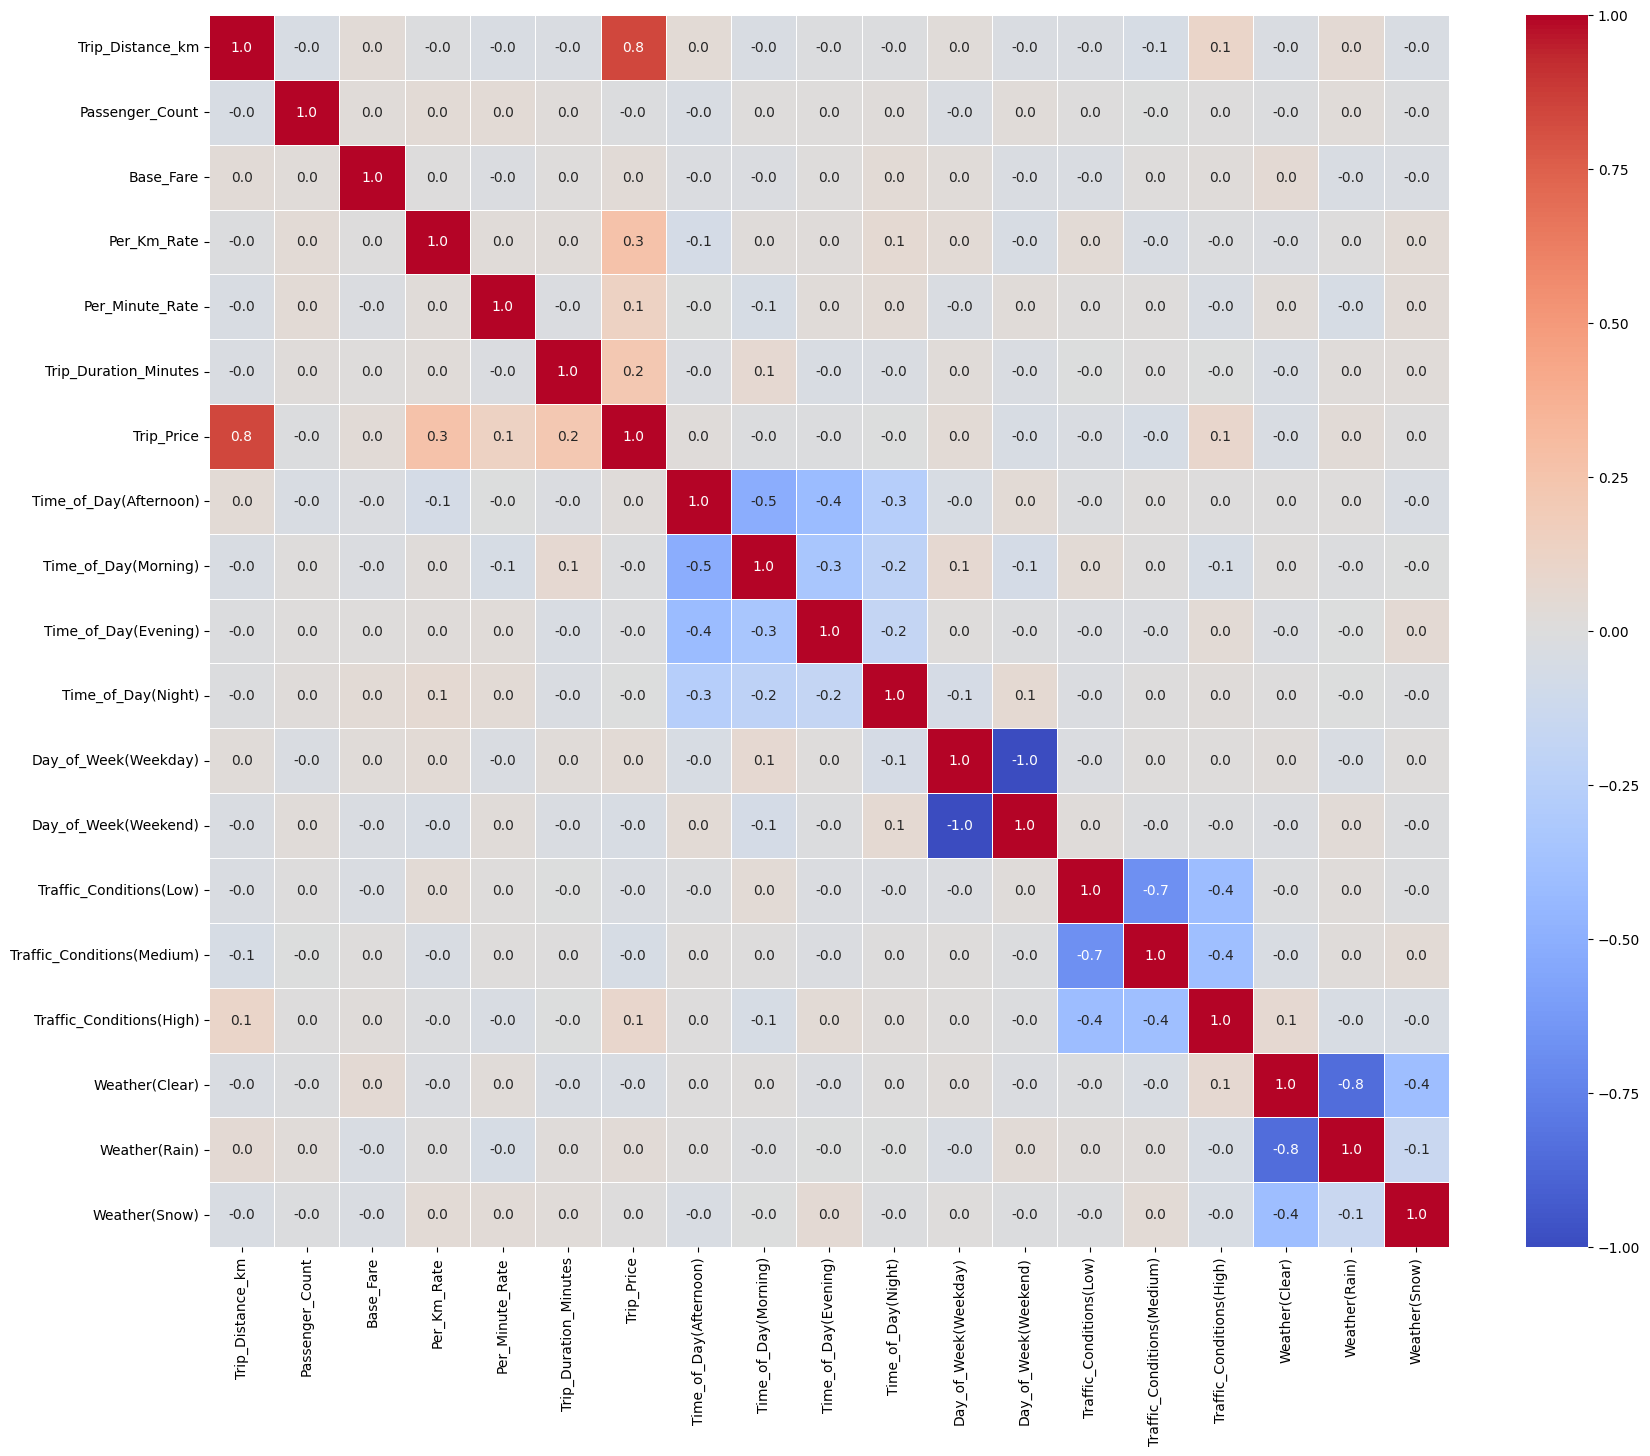

In [12]:
plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(numeric_only = True), annot = True,fmt = '.1f', cmap = 'coolwarm', linewidths=0.5)

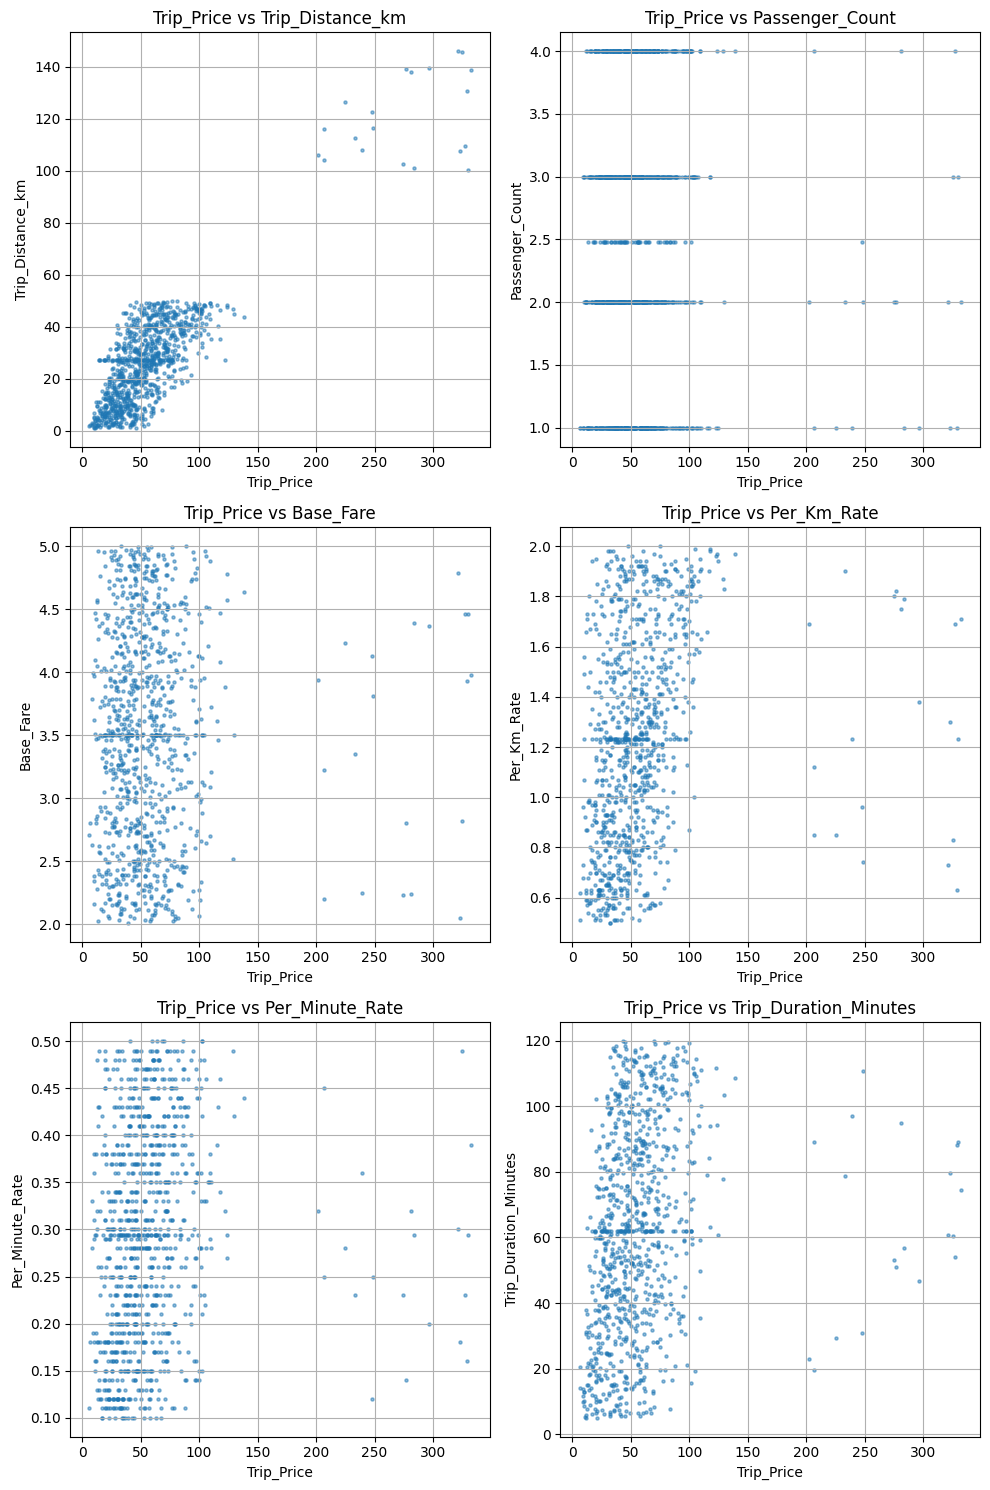

In [13]:
fts = []
for f in data.columns:
    if f=='Trip_Price':
        break
    fts.append(f)
cols = 2
rows = math.ceil(len(fts)/2)
fig, ax = plt.subplots(rows, cols, figsize = (10,15))
ax = ax.flatten()
for i,j in enumerate(fts):
    ax[i].scatter(data['Trip_Price'], data[j], alpha = 0.5, s=5)
    ax[i].set_title(f'Trip_Price vs {j}')
    ax[i].set_xlabel('Trip_Price')
    ax[i].set_ylabel(j)
    ax[i].grid()
plt.tight_layout()
for i in range(len(fts), len(ax)):
    plt.delaxes(ax[i])


**EDA:**
After taking a look at the results of the heatmap and the plots of dependencies between the first 4 features and the target feature, a.k.a. 'Trip_Price', we can conclude that 'Trip_Distance_km' has the most impact on the target (positive correlation ~0.8). The feature with the second most impact is 'Per_Km_Rate' (correlation ~0.3), the third is 'Trip_Duration_Minutes' (correlation ~0.2). All other features have almost no impact on 'Trip_Price'.

In [14]:
x = data.drop('Trip_Price', axis=1).values
y = data['Trip_Price'].values

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
sc = MinMaxScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [16]:
def evaluate(name, model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    rmse1 = root_mean_squared_error(y_train, model.predict(x_train))
    rmse2 = root_mean_squared_error(y_test, model.predict(x_test))
    r1 = r2_score(y_train, model.predict(x_train))
    r2 = r2_score(y_test, model.predict(x_test))
    print(f'''{name} - Prediction on Training data
                Mse: {rmse1}
                R^2: {r1}''')
    print(f'''{name} - Prediction on Testing data
                Mse: {rmse2}
                R^2: {r2}''')
    return {'name':name, 'R^2': r2, 'Rmse2':rmse2, 'model':model, 'x_test':x_test}

In [17]:
results = []

for name, model in [('Linear',LinearRegression()),('Ridge', Ridge()), ('Lasso', Lasso())]:
    results.append(evaluate(name, model, x_train_sc, x_test_sc, y_train, y_test))

for i in range(2,6):
    poly = PolynomialFeatures(degree = i)
    x_train_poly = poly.fit_transform(x_train_sc)
    x_test_poly = poly.transform(x_test_sc)
    results.append(evaluate(f"Polynomial^{i}", LinearRegression(), x_train_poly, x_test_poly, y_train, y_test))



Linear - Prediction on Training data
                Mse: 14.452235967054257
                R^2: 0.856577207233908
Linear - Prediction on Testing data
                Mse: 16.982247610746352
                R^2: 0.8766153234869852
Ridge - Prediction on Training data
                Mse: 14.613438258849872
                R^2: 0.8533598469187147
Ridge - Prediction on Testing data
                Mse: 17.896999468617157
                R^2: 0.8629650519451197
Lasso - Prediction on Training data
                Mse: 17.4868375688196
                R^2: 0.7900235256926913
Lasso - Prediction on Testing data
                Mse: 22.661817708018567
                R^2: 0.7802846634243333
Polynomial^2 - Prediction on Training data
                Mse: 7.653614694234562
                R^2: 0.9597763685508709
Polynomial^2 - Prediction on Testing data
                Mse: 14.697534822412063
                R^2: 0.9075812937240368
Polynomial^3 - Prediction on Training data
                Mse: 

In [18]:
df = pd.DataFrame(results).drop(columns = ['model','x_test'])
df.sort_values('R^2', ascending = False)


,name,R^2,Rmse2
3,Polynomial^2,0.907581,14.697535
0,Linear,0.876615,16.982248
1,Ridge,0.862965,17.896999
2,Lasso,0.780285,22.661818
4,Polynomial^3,0.761109,23.630058
6,Polynomial^5,0.585040,31.143511
5,Polynomial^4,0.332793,39.490689


In [19]:
def diff_plot(name, model, x_test, y_test):
    y_pr = model.predict(x_test)
    args_sorted = np.argsort(y_test)
    y_test_sorted = y_test[args_sorted]
    y_pr_sorted = y_pr[args_sorted]
    plt.plot(y_test_sorted, y_test_sorted, color = 'r', linestyle = '--', label = 'Perfect prediction')
    plt.scatter(y_test_sorted, y_pr_sorted, alpha = 0.5, s = 5, label = 'Predicted values')
    plt.title(f'{name} Prediction')
    plt.xlabel('Actual value')
    plt.ylabel('Predicted value')
    plt.legend()
    plt.grid(alpha = 0.3)
    plt.show()

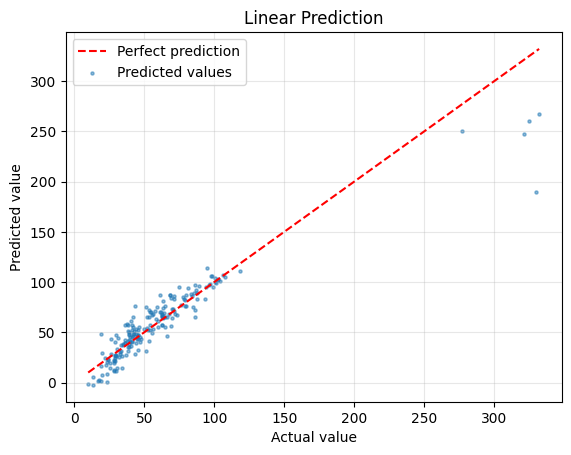

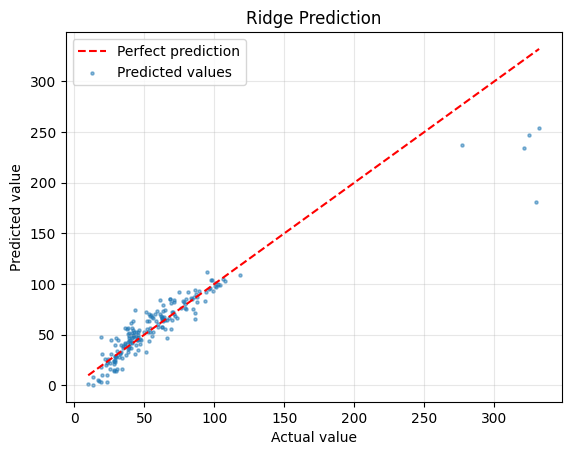

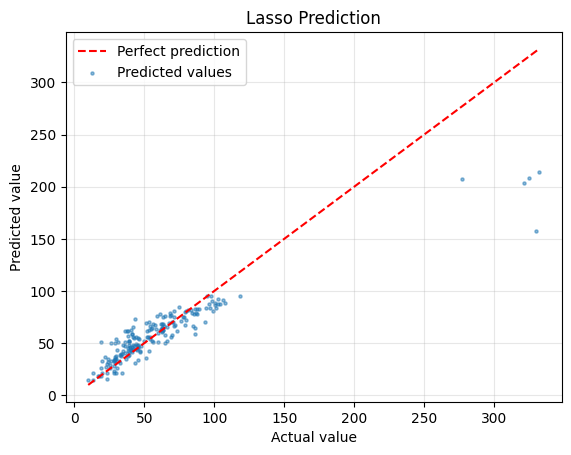

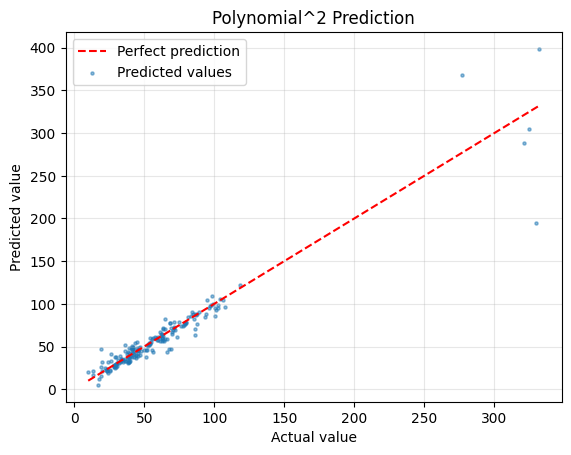

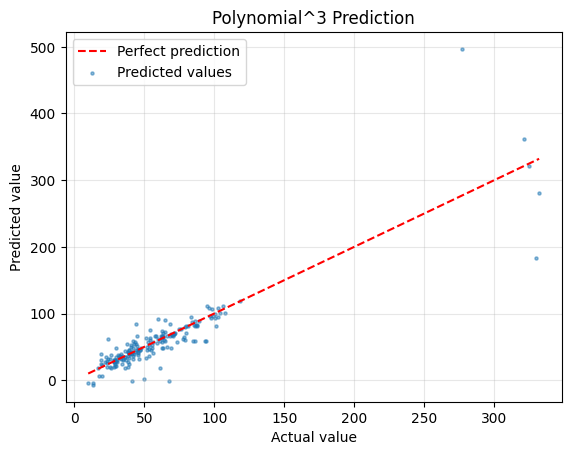

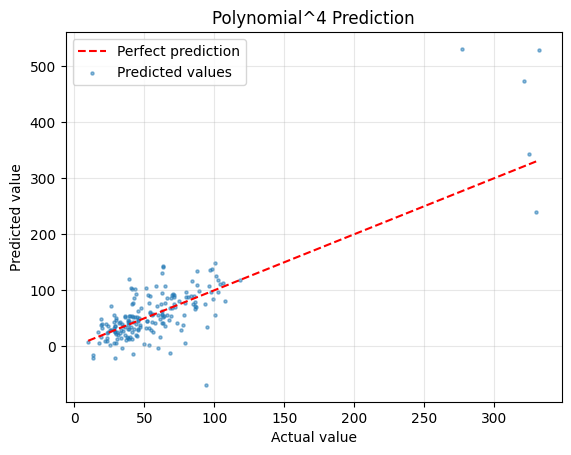

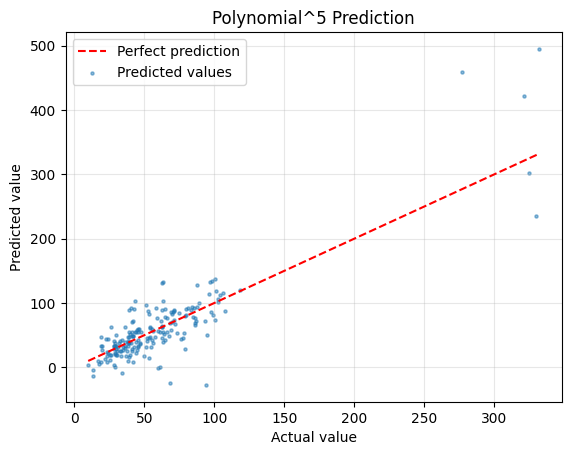

In [20]:
for r in results:
    diff_plot(r['name'], r['model'], r['x_test'], y_test)

In [21]:
from sklearn.pipeline import Pipeline

print("5-Fold Cross-Validation R² scores:\n")
for name, model in [('Linear', LinearRegression()),
                    ('Ridge',  Ridge(alpha=0.5)),
                    ('Lasso',  Lasso(alpha=0.5))]:
    scores = cross_val_score(model, x_train_sc, y_train, cv=5, scoring='r2')
    print(f"  {name:10s} →  mean: {scores.mean():.4f}   std: {scores.std():.4f}")
for degree in range(2, 5):
    pipeline = Pipeline([
        ('poly',  PolynomialFeatures(degree=degree)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipeline, x_train_sc, y_train, cv=5, scoring='r2')
    print(f"  {'Polynomial deg '+str(degree):20s} →  mean: {scores.mean():.4f}   std: {scores.std():.4f}")

5-Fold Cross-Validation R² scores:

  Linear     →  mean: 0.8466   std: 0.0391
  Ridge      →  mean: 0.8467   std: 0.0419
  Lasso      →  mean: 0.8364   std: 0.0492
  Polynomial deg 2     →  mean: 0.9018   std: 0.0503
  Polynomial deg 3     →  mean: -1.5741   std: 3.5680
  Polynomial deg 4     →  mean: 0.5166   std: 0.0808


## <span style="color: deeppink">Conclusion:</span> 
**Winner:** After training and evaluating multiple regression models on the taxi pricing dataset, the best performing model was **Polynomial Regression (degree 2)** with an <u>R² of 0.907</u> and an <u>RMSE of 14.75</u>, meaning the model explains ~90% of the variance in trip prices with an average error of roughly $14.75.
Linear Regression and Ridge performed comparably well with R² scores of 0.877 and 0.863 respectively, suggesting the data has a strong linear component. Lasso underperformed slightly, likely due to over-penalizing important features.
Higher degree polynomials (3, 4, 5) showed a clear overfitting trend — despite more complexity, their performance degraded significantly, with Polynomial degree 4 collapsing to an R² of just 0.239, indicating it fits noise rather than the underlying pattern.